<a href="https://colab.research.google.com/github/divyasri2609/Medical-Transcriptions/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn wordcloud

In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

import zipfile
import os

zip_path = "/content/archive (10).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files extracted:", os.listdir("data"))

Saving archive (10).zip to archive (10) (1).zip
Files extracted: ['mtsamples.csv']


In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns)

print("\nData Info:")
print(df.info())

Shape of dataset: (4966, 8)

Columns: Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords', 'text_length', 'clean_text'],
      dtype='object')

Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 4966 entries, 0 to 4998
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4966 non-null   int64 
 1   description        4966 non-null   object
 2   medical_specialty  4966 non-null   object
 3   sample_name        4966 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3898 non-null   object
 6   text_length        4966 non-null   int64 
 7   clean_text         4966 non-null   object
dtypes: int64(2), object(6)
memory usage: 349.2+ KB
None


In [ ]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

missing_percent = (missing_values / len(df)) * 100
print("\nMissing Percentage:\n", missing_percent)

Missing Values:
 Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription           0
keywords             1068
text_length             0
clean_text              0
dtype: int64

Missing Percentage:
 Unnamed: 0            0.000000
description           0.000000
medical_specialty     0.000000
sample_name           0.000000
transcription         0.000000
keywords             21.506242
text_length           0.000000
clean_text            0.000000
dtype: float64


In [ ]:
# Justification:
# - Transcription is essential → drop rows where it is missing
# - Specialty is target variable → cannot be null

df_clean = df.dropna(subset=['transcription', 'medical_specialty'])

print("New shape after cleaning:", df_clean.shape)

New shape after cleaning: (4966, 8)


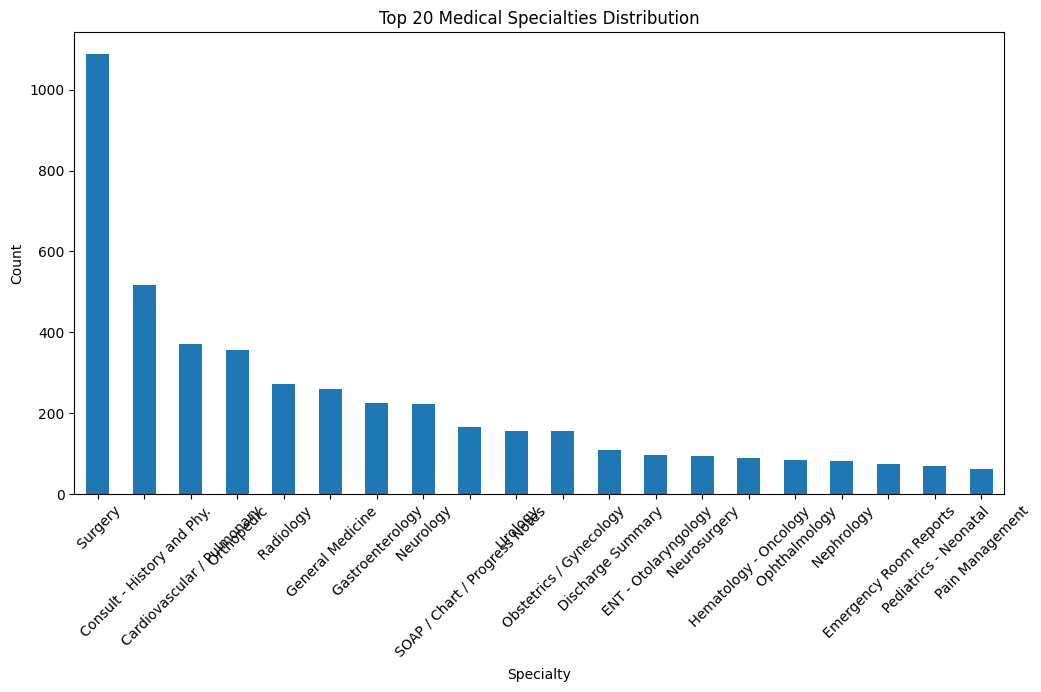

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
df_clean['medical_specialty'].value_counts().head(20).plot(kind='bar')

plt.title("Top 20 Medical Specialties Distribution")
plt.xlabel("Specialty")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

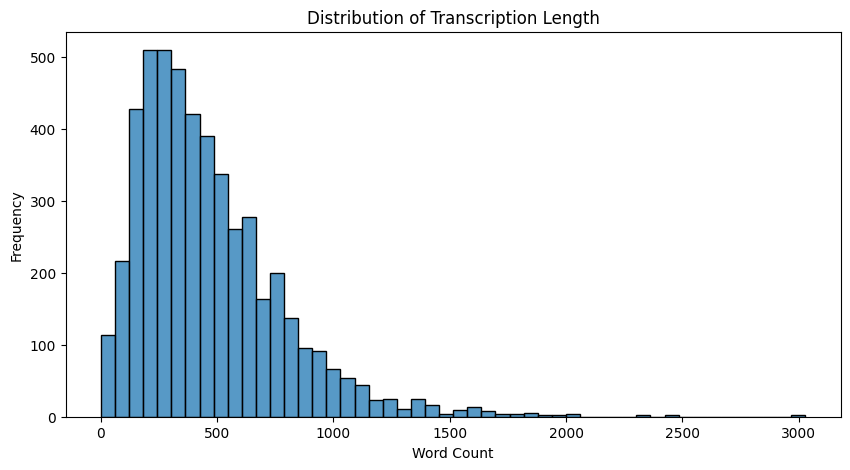

In [ ]:
df_clean['text_length'] = df_clean['transcription'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(df_clean['text_length'], bins=50)

plt.title("Distribution of Transcription Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

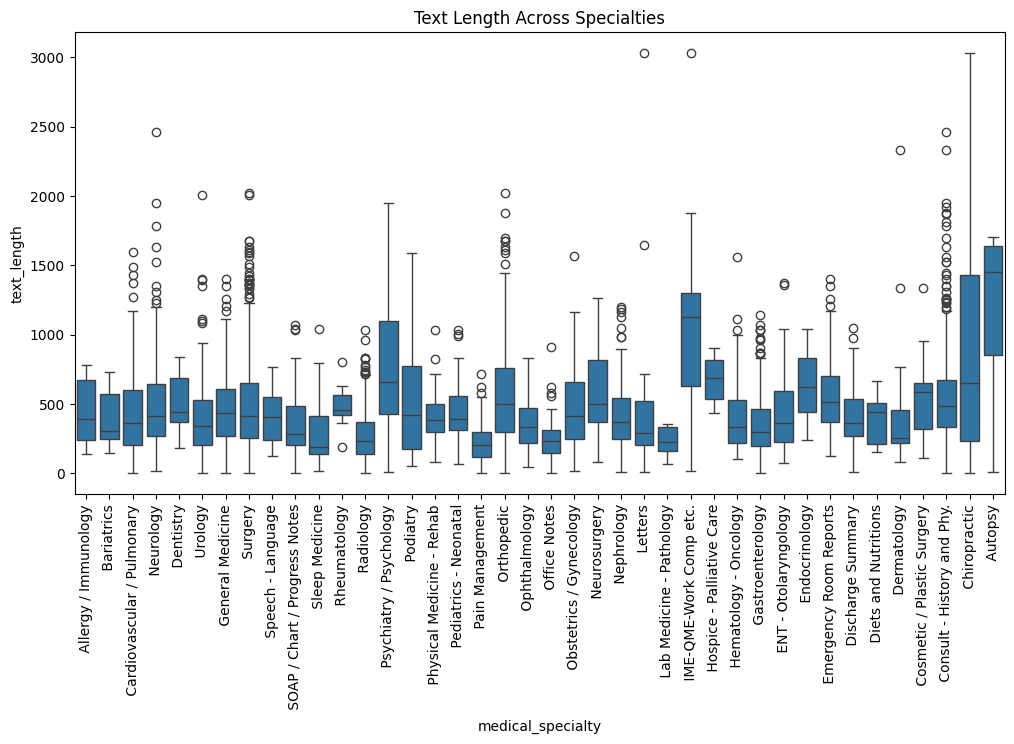

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df_clean['medical_specialty'],
    y=df_clean['text_length']
)

plt.xticks(rotation=90)
plt.title("Text Length Across Specialties")
plt.show()

In [ ]:
short_notes = df_clean[df_clean['text_length'] < 10]
print("Very Short Notes:", short_notes.shape)

long_notes = df_clean[df_clean['text_length'] > 1000]
print("Very Long Notes:", long_notes.shape)

Very Short Notes: (40, 8)
Very Long Notes: (285, 8)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

top_specialties = df_clean['medical_specialty'].value_counts().head(5).index
df_top = df_clean[df_clean['medical_specialty'].isin(top_specialties)]

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)

X = tfidf.fit_transform(df_top['transcription'])
feature_names = tfidf.get_feature_names_out()

In [ ]:
import numpy as np

for specialty in top_specialties:
    subset = df_top[df_top['medical_specialty'] == specialty]

    tfidf_sub = TfidfVectorizer(stop_words='english', max_features=1000)
    X_sub = tfidf_sub.fit_transform(subset['transcription'])

    scores = np.mean(X_sub.toarray(), axis=0)
    top_words = np.array(tfidf_sub.get_feature_names_out())[scores.argsort()[-10:]]

    print(f"\nTop words for {specialty}:")
    print(top_words)


Top words for  Surgery:
['used' 'anesthesia' 'incision' 'diagnosis' 'using' 'placed' 'procedure'
 'left' 'right' 'patient']

Top words for  Consult - History and Phy.:
['negative' 'past' 'denies' 'left' 'right' 'mg' 'pain' 'normal' 'history'
 'patient']

Top words for  Cardiovascular / Pulmonary:
['chest' 'mg' 'coronary' 'procedure' 'normal' 'history' 'artery' 'right'
 'left' 'patient']

Top words for  Orthopedic:
['history' 'tendon' 'fracture' 'procedure' 'knee' 'placed' 'pain' 'left'
 'right' 'patient']

Top words for  Radiology:
['evidence' 'mild' 'ct' 'seen' 'unremarkable' 'exam' 'patient' 'right'
 'normal' 'left']


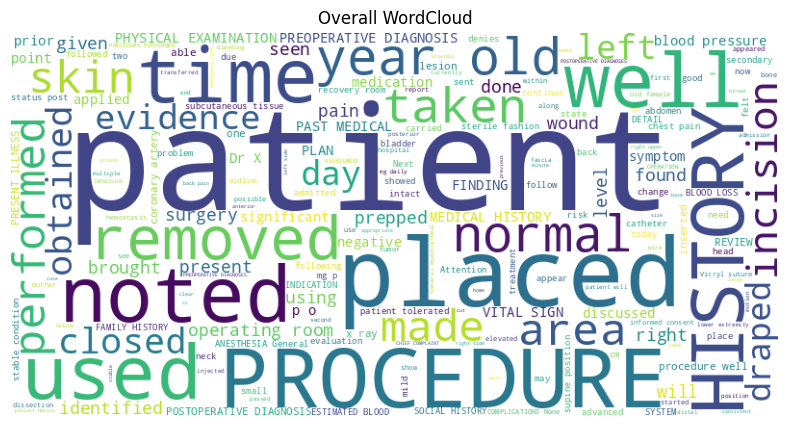

In [ ]:
from wordcloud import WordCloud

text = " ".join(df_clean['transcription'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Overall WordCloud")
plt.show()